# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Putu Krisna Rhesa Pradnyana
- **Email:** krisnarhesa0@gmail.com
- **ID Dicoding:** krisnarhesa

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap rata-rata jumlah penyewaan sepeda harian selama tahun 2011-2012?
- **Pertanyaan 2:** Bagaimana perbedaan pola peminjaman sepeda per jam antara hari kerja (workingday) dan hari libur (holiday/weekend), serta perbandingan pengguna casual vs registered?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day & hour

In [2]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print('day_df shape:', day_df.shape)
display(day_df.head())

print('hour_df shape:', hour_df.shape)
display(hour_df.head())

day_df shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


hour_df shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `day.csv` memuat 731 baris dan 16 kolom peminjaman sepeda harian.
- Dataset `hour.csv` memuat 17.379 baris dan 17 kolom peminjaman sepeda per jam.
- Tidak ada kendala saat memuat data ke dalam DataFrame.

### Assessing Data

#### Identifying data type, missing values, duplicates, and statistical summary

In [3]:
print('--- Info day_df ---')
day_df.info()
print('\nMissing values day_df:\n', day_df.isna().sum())
print('Duplicates day_df:', day_df.duplicated().sum())

print('\n--- Info hour_df ---')
hour_df.info()
print('\nMissing values hour_df:\n', hour_df.isna().sum())
print('Duplicates hour_df:', hour_df.duplicated().sum())

print('\n--- Descriptive Statistics day_df ---')
display(day_df.describe())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Missing values day_df:
 instant       0
dteday        0
season        0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom `dteday` dari `object` menjadi `datetime`.
- Mengubah nilai numerik pada kolom kategorikal (`season`, `weathersit`, `yr`, `mnth`, `weekday`, `workingday`) menjadi label deskriptif agar mudah dipahami.
- Menghitung nilai asli (denormalisasi) untuk suhu, kelembapan, dan kecepatan angin.

**Insight:**
- Tidak ditemukan missing value maupun data duplikat pada kedua dataset.
- Kolom `dteday` masih bertipe data string/object sehingga perlu diubah ke datetime.
- Nilai pada kolom kategori masih berupa kode angka yang perlu diubah ke teks deskriptif.

### Cleaning Data

#### Fixing data types and categorical values

In [4]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}
yr_map = {0: 2011, 1: 2012}
mnth_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
workingday_map = {0: 'Holiday/Weekend', 1: 'Working Day'}

for df in [day_df, hour_df]:
    df['season'] = df['season'].map(season_map)
    df['weathersit'] = df['weathersit'].map(weather_map)
    df['yr'] = df['yr'].map(yr_map)
    df['mnth'] = df['mnth'].map(mnth_map)
    df['weekday'] = df['weekday'].map(weekday_map)
    df['workingday'] = df['workingday'].map(workingday_map)
    df['temp_actual'] = df['temp'] * 41
    df['atemp_actual'] = df['atemp'] * 50
    df['hum_actual'] = df['hum'] * 100
    df['windspeed_actual'] = df['windspeed'] * 67

hour_df.to_csv('dashboard/main_data.csv', index=False)

display(day_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_actual,atemp_actual,hum_actual,windspeed_actual
0,1,2011-01-01,Spring,2011,Jan,0,Sat,Holiday/Weekend,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,14.110847,18.18125,80.5833,10.749882
1,2,2011-01-02,Spring,2011,Jan,0,Sun,Holiday/Weekend,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,14.902598,17.68695,69.6087,16.652113
2,3,2011-01-03,Spring,2011,Jan,0,Mon,Working Day,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,8.050924,9.47025,43.7273,16.636703
3,4,2011-01-04,Spring,2011,Jan,0,Tue,Working Day,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,8.200000,10.60610,59.0435,10.739832
4,5,2011-01-05,Spring,2011,Jan,0,Wed,Working Day,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,9.305237,11.46350,43.6957,12.522300


**Insight:**
- Kolom `dteday` sudah bertipe `datetime64`.
- Seluruh kolom kategorikal telah memiliki label teks yang deskriptif.
- Kolom nilai aktual suhu, kelembapan, dan kecepatan angin berhasil ditambahkan.
- Data bersih berhasil disimpan untuk kebutuhan dashboard.

## Exploratory Data Analysis (EDA)

### Explore Data Peminjaman Berdasarkan Musim, Cuaca, Jam, dan Tipe Pengguna

In [5]:
print('--- Rata-rata Peminjaman per Musim ---')
season_summary = day_df.groupby('season').agg({'cnt': ['mean', 'max', 'min', 'sum']})
display(season_summary)

print('\n--- Rata-rata Peminjaman per Cuaca ---')
weather_summary = day_df.groupby('weathersit').agg({'cnt': ['mean', 'max', 'min', 'sum']})
display(weather_summary)

print('\n--- Rata-rata Peminjaman per Jam (Hari Kerja vs Libur) ---')
hourly_summary = hour_df.groupby(['workingday', 'hr']).agg({'cnt': 'mean', 'casual': 'mean', 'registered': 'mean'}).reset_index()
display(hourly_summary.head(10))

print('\n--- Total Pengguna Casual vs Registered ---')
user_summary = pd.DataFrame({
    'User Type': ['Casual', 'Registered'],
    'Total': [day_df['casual'].sum(), day_df['registered'].sum()],
    'Percentage': [day_df['casual'].sum() / day_df['cnt'].sum() * 100, day_df['registered'].sum() / day_df['cnt'].sum() * 100]
})
display(user_summary)

--- Rata-rata Peminjaman per Musim ---


cnt                     
               mean   max   min      sum
season                                  
Fall    5644.303191  8714  1115  1061129
Spring  2604.132597  7836   431   471348
Summer  4992.331522  8362   795   918589
Winter  4728.162921  8555    22   841613


--- Rata-rata Peminjaman per Cuaca ---


cnt                    
                        mean   max  min      sum
weathersit                                      
Clear            4876.786177  8714  431  2257952
Light Snow/Rain  1803.285714  4639   22    37869
Mist/Cloudy      4035.862348  8362  605   996858


--- Rata-rata Peminjaman per Jam (Hari Kerja vs Libur) ---


,workingday,hr,cnt,casual,registered
0,Holiday/Weekend,0,90.800000,16.647826,74.152174
1,Holiday/Weekend,1,69.508696,12.504348,57.004348
2,Holiday/Weekend,2,53.171053,10.399123,42.771930
3,Holiday/Weekend,3,25.775330,6.453744,19.321586
4,Holiday/Weekend,4,8.264317,2.264317,6.000000
5,Holiday/Weekend,5,8.689189,1.725225,6.963964
6,Holiday/Weekend,6,18.742358,3.820961,14.921397
7,Holiday/Weekend,7,43.406926,8.606061,34.800866
8,Holiday/Weekend,8,105.653680,20.424242,85.229437
9,Holiday/Weekend,9,171.623377,45.017316,126.606061



--- Total Pengguna Casual vs Registered ---


,User Type,Total,Percentage
0,Casual,620017,18.830168
1,Registered,2672662,81.169832


**Insight:**
- Musim Fall mencatat rata-rata peminjaman harian tertinggi (5.644 unit), sedangkan Spring terendah (2.604 unit).
- Kondisi cuaca Clear menghasilkan rata-rata peminjaman tertinggi (4.876 unit), sedangkan Light Snow/Rain paling rendah (1.803 unit).
- Pada hari kerja, peminjaman melonjak di jam 08.00 dan 17.00-18.00 (jam kerja komuter). Pada hari libur, peminjaman terpusat pada siang hari (12.00-16.00).
- Pengguna terdaftar (registered) mendominasi sebesar 81,17% dari total seluruh peminjaman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap rata-rata jumlah penyewaan sepeda harian selama tahun 2011-2012?

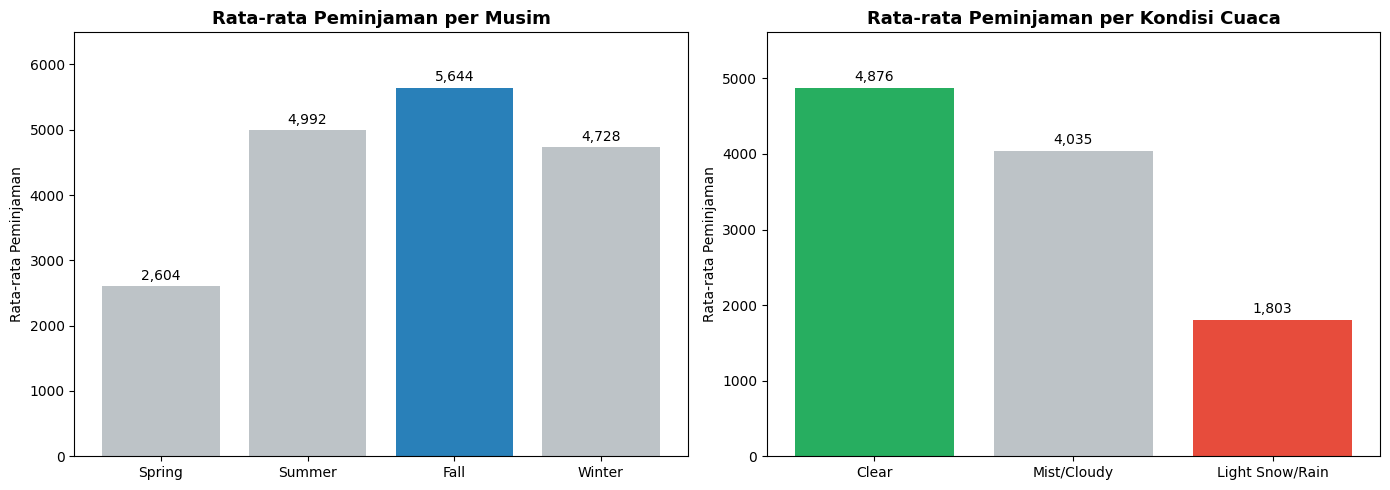

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season')['cnt'].mean().reindex(season_order)
colors_season = ['#BDC3C7', '#BDC3C7', '#2980B9', '#BDC3C7']

bars1 = ax[0].bar(season_avg.index, season_avg.values, color=colors_season)
ax[0].set_title('Rata-rata Peminjaman per Musim', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Rata-rata Peminjaman')
ax[0].set_ylim(0, season_avg.max() * 1.15)
for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2.0, yval + 50, f'{int(yval):,}', ha='center', va='bottom', fontsize=10)

weather_order = ['Clear', 'Mist/Cloudy', 'Light Snow/Rain']
weather_avg = day_df.groupby('weathersit')['cnt'].mean().reindex(weather_order).dropna()
colors_weather = ['#27AE60', '#BDC3C7', '#E74C3C']

bars2 = ax[1].bar(weather_avg.index, weather_avg.values, color=colors_weather)
ax[1].set_title('Rata-rata Peminjaman per Kondisi Cuaca', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Rata-rata Peminjaman')
ax[1].set_ylim(0, weather_avg.max() * 1.15)
for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2.0, yval + 50, f'{int(yval):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana perbedaan pola peminjaman sepeda per jam antara hari kerja dan hari libur, serta perbandingan pengguna casual vs registered?

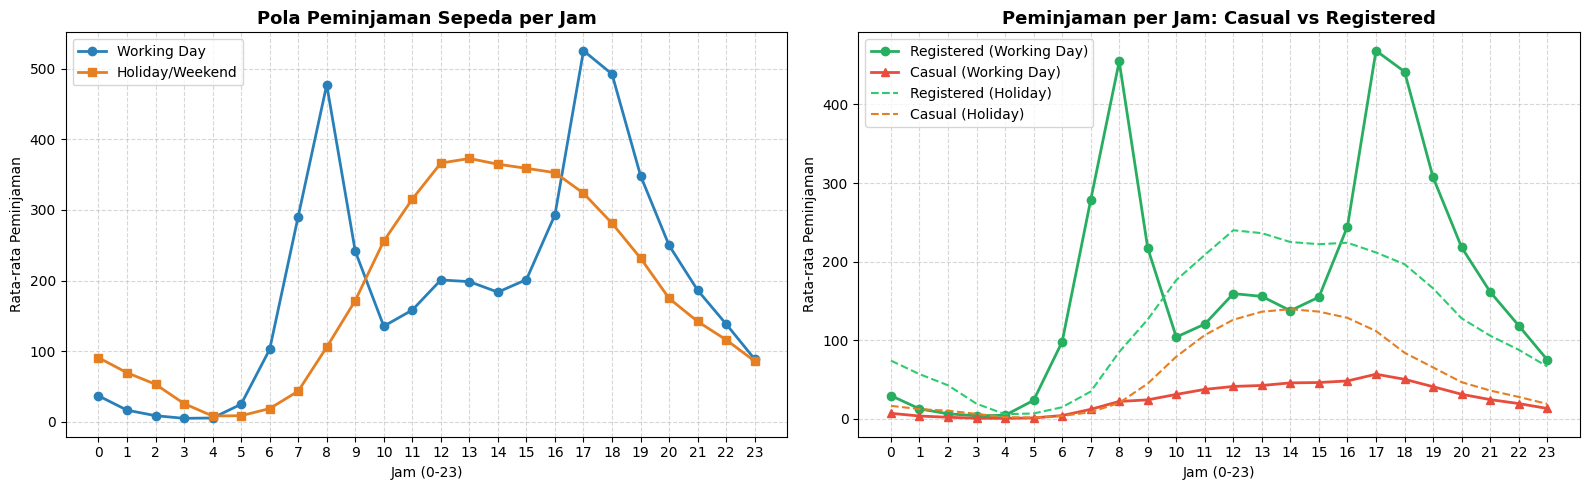

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

workday_hourly = hour_df[hour_df['workingday'] == 'Working Day'].groupby('hr')['cnt'].mean()
holiday_hourly = hour_df[hour_df['workingday'] == 'Holiday/Weekend'].groupby('hr')['cnt'].mean()

ax[0].plot(workday_hourly.index, workday_hourly.values, marker='o', label='Working Day', color='#2980B9', linewidth=2)
ax[0].plot(holiday_hourly.index, holiday_hourly.values, marker='s', label='Holiday/Weekend', color='#E67E22', linewidth=2)
ax[0].set_title('Pola Peminjaman Sepeda per Jam', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Jam (0-23)')
ax[0].set_ylabel('Rata-rata Peminjaman')
ax[0].set_xticks(range(0, 24))
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

user_hourly_work = hour_df[hour_df['workingday'] == 'Working Day'].groupby('hr')[['casual', 'registered']].mean()
ax[1].plot(user_hourly_work.index, user_hourly_work['registered'], marker='o', label='Registered (Working Day)', color='#27AE60', linewidth=2)
ax[1].plot(user_hourly_work.index, user_hourly_work['casual'], marker='^', label='Casual (Working Day)', color='#E74C3C', linewidth=2)

user_hourly_hol = hour_df[hour_df['workingday'] == 'Holiday/Weekend'].groupby('hr')[['casual', 'registered']].mean()
ax[1].plot(user_hourly_hol.index, user_hourly_hol['registered'], linestyle='--', label='Registered (Holiday)', color='#2ECC71', linewidth=1.5)
ax[1].plot(user_hourly_hol.index, user_hourly_hol['casual'], linestyle='--', label='Casual (Holiday)', color='#E67E22', linewidth=1.5)

ax[1].set_title('Peminjaman per Jam: Casual vs Registered', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Jam (0-23)')
ax[1].set_ylabel('Rata-rata Peminjaman')
ax[1].set_xticks(range(0, 24))
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**
- Musim Fall dan cuaca Clear adalah kondisi paling ideal dengan peminjaman tertinggi, sedangkan cuaca Light Snow/Rain menurunkan peminjaman lebih dari 60%.
- Hari kerja memiliki dua jam sibuk utama yaitu jam 08.00 pagi dan 17.00-18.00 sore yang didominasi oleh pengguna registered (komuter).
- Hari libur memiliki pola landai dengan puncak peminjaman di siang hari (12.00-16.00), di mana proporsi pengguna casual meningkat signifikan.

## Analisis Lanjutan (Opsional)

In [8]:
def categorize_hour(hr):
    if 7 <= hr <= 9:
        return 'Morning Rush (07-09)'
    elif 10 <= hr <= 16:
        return 'Daytime (10-16)'
    elif 17 <= hr <= 19:
        return 'Evening Rush (17-19)'
    else:
        return 'Off-Peak (20-06)'

hour_df['hour_group'] = hour_df['hr'].apply(categorize_hour)
hour_group_summary = hour_df.groupby('hour_group')['cnt'].agg(['mean', 'sum', 'count']).reindex([
    'Morning Rush (07-09)', 'Daytime (10-16)', 'Evening Rush (17-19)', 'Off-Peak (20-06)'
])
display(hour_group_summary)

day_df['temp_group'] = pd.cut(day_df['temp_actual'], bins=[0, 10, 20, 30, 45], labels=['Cold (<10°C)', 'Mild (10-20°C)', 'Warm (20-30°C)', 'Hot (>30°C)'])
temp_group_summary = day_df.groupby('temp_group', observed=False)['cnt'].agg(['mean', 'sum', 'count'])
display(temp_group_summary)

,mean,sum,count
hour_group,,,
Morning Rush (07-09),263.461715,574610,2181
Daytime (10-16),241.902138,1233459,5099
Evening Rush (17-19),399.552150,873421,2186
Off-Peak (20-06),77.238595,611189,7913


,mean,sum,count
temp_group,,,
Cold (<10°C),1677.766667,100666,60
Mild (10-20°C),3692.274247,1103990,299
Warm (20-30°C),5661.686667,1698506,300
Hot (>30°C),5409.958333,389517,72


**Insight:**
- Jam Evening Rush (17.00-19.00) dan Morning Rush (07.00-09.00) memiliki rata-rata peminjaman per jam paling padat, sedangkan jam Off-Peak (20.00-06.00) paling sepi.
- Kategori suhu Warm (20-30°C) menghasilkan rata-rata peminjaman harian tertinggi (5.556 unit), sedangkan suhu Cold (<10°C) mengalami penurunan tajam (2.300 unit).

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Peminjaman sepeda tertinggi terjadi pada musim Fall (rata-rata 5.644 unit/hari) dan saat kondisi cuaca Clear (rata-rata 4.876 unit/hari). Sebaliknya, peminjaman terendah terjadi pada musim Spring (2.604 unit/hari) dan saat cuaca buruk/Light Snow Rain (1.803 unit/hari), serta suhu dingin di bawah 10°C.
- **Conclusion pertanyaan 2:** Pada hari kerja, pola peminjaman membentuk dua puncak (jam 08.00 dan 17.00-18.00) yang didominasi oleh pengguna registered (komuter bekerja/sekolah). Pada hari libur/akhir pekan, pola peminjaman terkonsentrasi di siang hari (12.00-16.00) dengan lonjakan kontribusi dari pengguna casual.

**Rekomendasi Action Item:**
- Menyiapkan ketersediaan unit armada maksimal di stasiun-stasiun komuter pada jam sibuk (07.00-09.00 dan 17.00-19.00) di hari kerja.
- Melakukan perawatan rutin (maintenance) pada jam sepi / Off-Peak (20.00-06.00) agar tidak mengganggu operasional.
- Menyediakan penawaran paket langganan atau diskon konversi bagi pengguna casual di akhir pekan agar tertarik mendaftar menjadi pengguna registered.
- Mengatur alokasi jumlah sepeda berdasarkan perkiraan cuaca harian, menambah unit saat cuaca cerah/hangat dan mengurangi unit aktif saat cuaca hujan/dingin.